In [1]:
# ============================================================
# FULL RECOVERY CELL — reinstalls, retrains, saves everything
# ============================================================
!pip install ultralytics -q

import os, shutil, random, cv2, numpy as np, torch
import torch.nn as nn, torch.optim as optim
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from ultralytics import YOLO
from PIL import Image

RAW    = '/kaggle/input/datasets/srijaroy01/tympanic-membrane/data'
BASE   = '/kaggle/working/TM_Project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}\n")

# ── Folders ──────────────────────────────────────────────
for split in ['train','val','test']:
    os.makedirs(f'{BASE}/dataset/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE}/dataset/labels/{split}',  exist_ok=True)
os.makedirs(f'{BASE}/runs', exist_ok=True)

# ── Remap + Split ─────────────────────────────────────────
CLASS_REMAP = {0:0, 10:2, 11:1}
all_files   = os.listdir(RAW)
pairs = [os.path.splitext(f)[0] for f in all_files
         if f.endswith('.txt') and f != 'classes.txt'
         and os.path.splitext(f)[0]+'.jpg' in all_files]

random.seed(42); random.shuffle(pairs)
n = len(pairs)
splits = {
    'train': pairs[:int(n*0.80)],
    'val':   pairs[int(n*0.80):int(n*0.95)],
    'test':  pairs[int(n*0.95):]
}
print(f"✓ Pairs: {n} | Train:{len(splits['train'])} Val:{len(splits['val'])} Test:{len(splits['test'])}")

for split, basenames in splits.items():
    for base in basenames:
        with open(f'{RAW}/{base}.txt') as f: lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts: continue
            new_cls = CLASS_REMAP.get(int(parts[0]), int(parts[0]))
            new_lines.append(f"{new_cls} {' '.join(parts[1:])}\n")
        with open(f'{BASE}/dataset/labels/{split}/{base}.txt','w') as f:
            f.writelines(new_lines)
        shutil.copy2(f'{RAW}/{base}.jpg', f'{BASE}/dataset/images/{split}/{base}.jpg')
print("✓ Files copied & remapped!")

# ── YAML ─────────────────────────────────────────────────
yaml_content = f"""path: {BASE}/dataset
train: images/train
val: images/val
test: images/test
nc: 3
names:
  0: Congestion
  1: Perforation
  2: Retraction
"""
with open(f'{BASE}/tm_dataset.yaml','w') as f: f.write(yaml_content)
print("✓ YAML saved!\n")

# ── YOLO Training ─────────────────────────────────────────
print("🚀 Starting YOLO training...")
yolo = YOLO('yolov8n.pt')
results = yolo.train(
    data=f'{BASE}/tm_dataset.yaml', epochs=100, imgsz=640,
    batch=16, patience=20, device=0, cls=1.0,
    project=f'{BASE}/runs', name='tm_detect_v1', exist_ok=True)
print(f"✓ YOLO done!\n")

# ── GrabCut masks ─────────────────────────────────────────
print("🚀 Generating GrabCut masks...")
MASK_OUT    = f'{BASE}/unet_data'
CLASS_NAMES = {0:'0_Congestion', 1:'1_Perforation', 2:'2_Retraction'}
for split in ['train','val','test']:
    for cls in CLASS_NAMES.values():
        os.makedirs(f'{MASK_OUT}/{split}/masks/{cls}', exist_ok=True)
        os.makedirs(f'{MASK_OUT}/{split}/images/{cls}', exist_ok=True)

def process_one(args):
    img_file, lbl_file, split = args
    img = cv2.imread(str(img_file))
    if img is None: return 0,1
    H,W = img.shape[:2]; count,fail = 0,0
    for line in open(lbl_file).readlines():
        parts = line.strip().split()
        if len(parts)<5: continue
        cls_id = int(parts[0]); cls_name = CLASS_NAMES.get(cls_id)
        if not cls_name: continue
        cx,cy,bw,bh = map(float,parts[1:5])
        x1=max(0,int((cx-bw/2)*W)); y1=max(0,int((cy-bh/2)*H))
        x2=min(W-1,int((cx+bw/2)*W)); y2=min(H-1,int((cy+bh/2)*H))
        if (x2-x1)<5 or (y2-y1)<5: fail+=1; continue
        try:
            mgc=np.zeros(img.shape[:2],np.uint8)
            cv2.grabCut(img,mgc,(x1,y1,x2-x1,y2-y1),
                np.zeros((1,65),np.float64),np.zeros((1,65),np.float64),
                5,cv2.GC_INIT_WITH_RECT)
            mask=np.where((mgc==cv2.GC_FGD)|(mgc==cv2.GC_PR_FGD),255,0).astype(np.uint8)
        except: fail+=1; continue
        cv2.imwrite(f'{MASK_OUT}/{split}/images/{cls_name}/{lbl_file.stem}.jpg',
                    cv2.resize(img[y1:y2,x1:x2],(256,256)))
        cv2.imwrite(f'{MASK_OUT}/{split}/masks/{cls_name}/{lbl_file.stem}.png',
                    cv2.resize(mask[y1:y2,x1:x2],(256,256)))
        count+=1
    return count,fail

tasks = []
for split in ['train','val','test']:
    for lbl in Path(f'{BASE}/dataset/labels/{split}').glob('*.txt'):
        img = Path(f'{BASE}/dataset/images/{split}')/(lbl.stem+'.jpg')
        if img.exists(): tasks.append((img,lbl,split))

total=failed=done=0
with ThreadPoolExecutor(max_workers=4) as ex:
    for fut in as_completed({ex.submit(process_one,t):t for t in tasks}):
        c,f=fut.result(); total+=c; failed+=f; done+=1
        if done%50==0: print(f"  GrabCut: {done}/{len(tasks)} done...")
print(f"✓ GrabCut done: {total} pairs, {failed} failed\n")

# ── U-Net ─────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),
            nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True))
    def forward(self,x): return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1=DoubleConv(3,64);   self.e2=DoubleConv(64,128)
        self.e3=DoubleConv(128,256);self.e4=DoubleConv(256,512)
        self.pool=nn.MaxPool2d(2);  self.bot=DoubleConv(512,1024)
        self.u4=nn.ConvTranspose2d(1024,512,2,2); self.d4=DoubleConv(1024,512)
        self.u3=nn.ConvTranspose2d(512,256,2,2);  self.d3=DoubleConv(512,256)
        self.u2=nn.ConvTranspose2d(256,128,2,2);  self.d2=DoubleConv(256,128)
        self.u1=nn.ConvTranspose2d(128,64,2,2);   self.d1=DoubleConv(128,64)
        self.out=nn.Conv2d(64,1,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1))
        e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bot(self.pool(e4))
        x=self.d4(torch.cat([self.u4(b),e4],1))
        x=self.d3(torch.cat([self.u3(x),e3],1))
        x=self.d2(torch.cat([self.u2(x),e2],1))
        x=self.d1(torch.cat([self.u1(x),e1],1))
        return self.out(x)

class TMDataset(Dataset):
    def __init__(self,split):
        self.pairs=[]
        for cf in Path(f'{MASK_OUT}/{split}/images').iterdir():
            for ip in cf.glob('*.jpg'):
                mp=Path(str(ip).replace('/images/','/masks/').replace('.jpg','.png'))
                if mp.exists(): self.pairs.append((ip,mp))
        print(f"  {split}: {len(self.pairs)} pairs")
        self.it=transforms.Compose([transforms.Resize((256,256)),transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
        self.mt=transforms.Compose([transforms.Resize((256,256)),transforms.ToTensor()])
    def __len__(self): return len(self.pairs)
    def __getitem__(self,i):
        ip,mp=self.pairs[i]
        return self.it(Image.open(ip).convert('RGB')),\
               (self.mt(Image.open(mp).convert('L'))>0.5).float()

print("🚀 Starting U-Net training...")
train_dl=DataLoader(TMDataset('train'),batch_size=8,shuffle=True,num_workers=2)
val_dl  =DataLoader(TMDataset('val'),  batch_size=8,shuffle=False,num_workers=2)
model=UNet().to(DEVICE)
crit=nn.BCEWithLogitsLoss()
opt=optim.Adam(model.parameters(),lr=1e-3)
sch=optim.lr_scheduler.ReduceLROnPlateau(opt,patience=5,factor=0.5)
SAVE_PATH=f'{BASE}/runs/unet_best.pt'
best=float('inf')

for ep in range(1,51):
    model.train(); tl=0
    for imgs,masks in train_dl:
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        opt.zero_grad(); loss=crit(model(imgs),masks)
        loss.backward(); opt.step(); tl+=loss.item()
    model.eval(); vl=0
    with torch.no_grad():
        for imgs,masks in val_dl:
            imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
            vl+=crit(model(imgs),masks).item()
    tl/=len(train_dl); vl/=len(val_dl); sch.step(vl)
    if vl<best:
        best=vl; torch.save(model.state_dict(),SAVE_PATH); flag=' <- best saved'
    else: flag=''
    if ep%5==0 or ep==1:
        print(f"Epoch {ep:3d}/50 | Train:{tl:.4f} | Val:{vl:.4f}{flag}")

print(f"\n✓ U-Net done! Best val loss: {best:.4f}")
print(f"✓ All done! Ready for inference.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.8 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda

✓ Pairs: 418 | Train:334 Val:63 Test:21
✓ Files copied & remapped!
✓ YAML saved!

🚀 Starting YOLO training...
Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/TM_Project/tm_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=

Device: cuda
✓ Both models loaded!
Running on 21 test images...


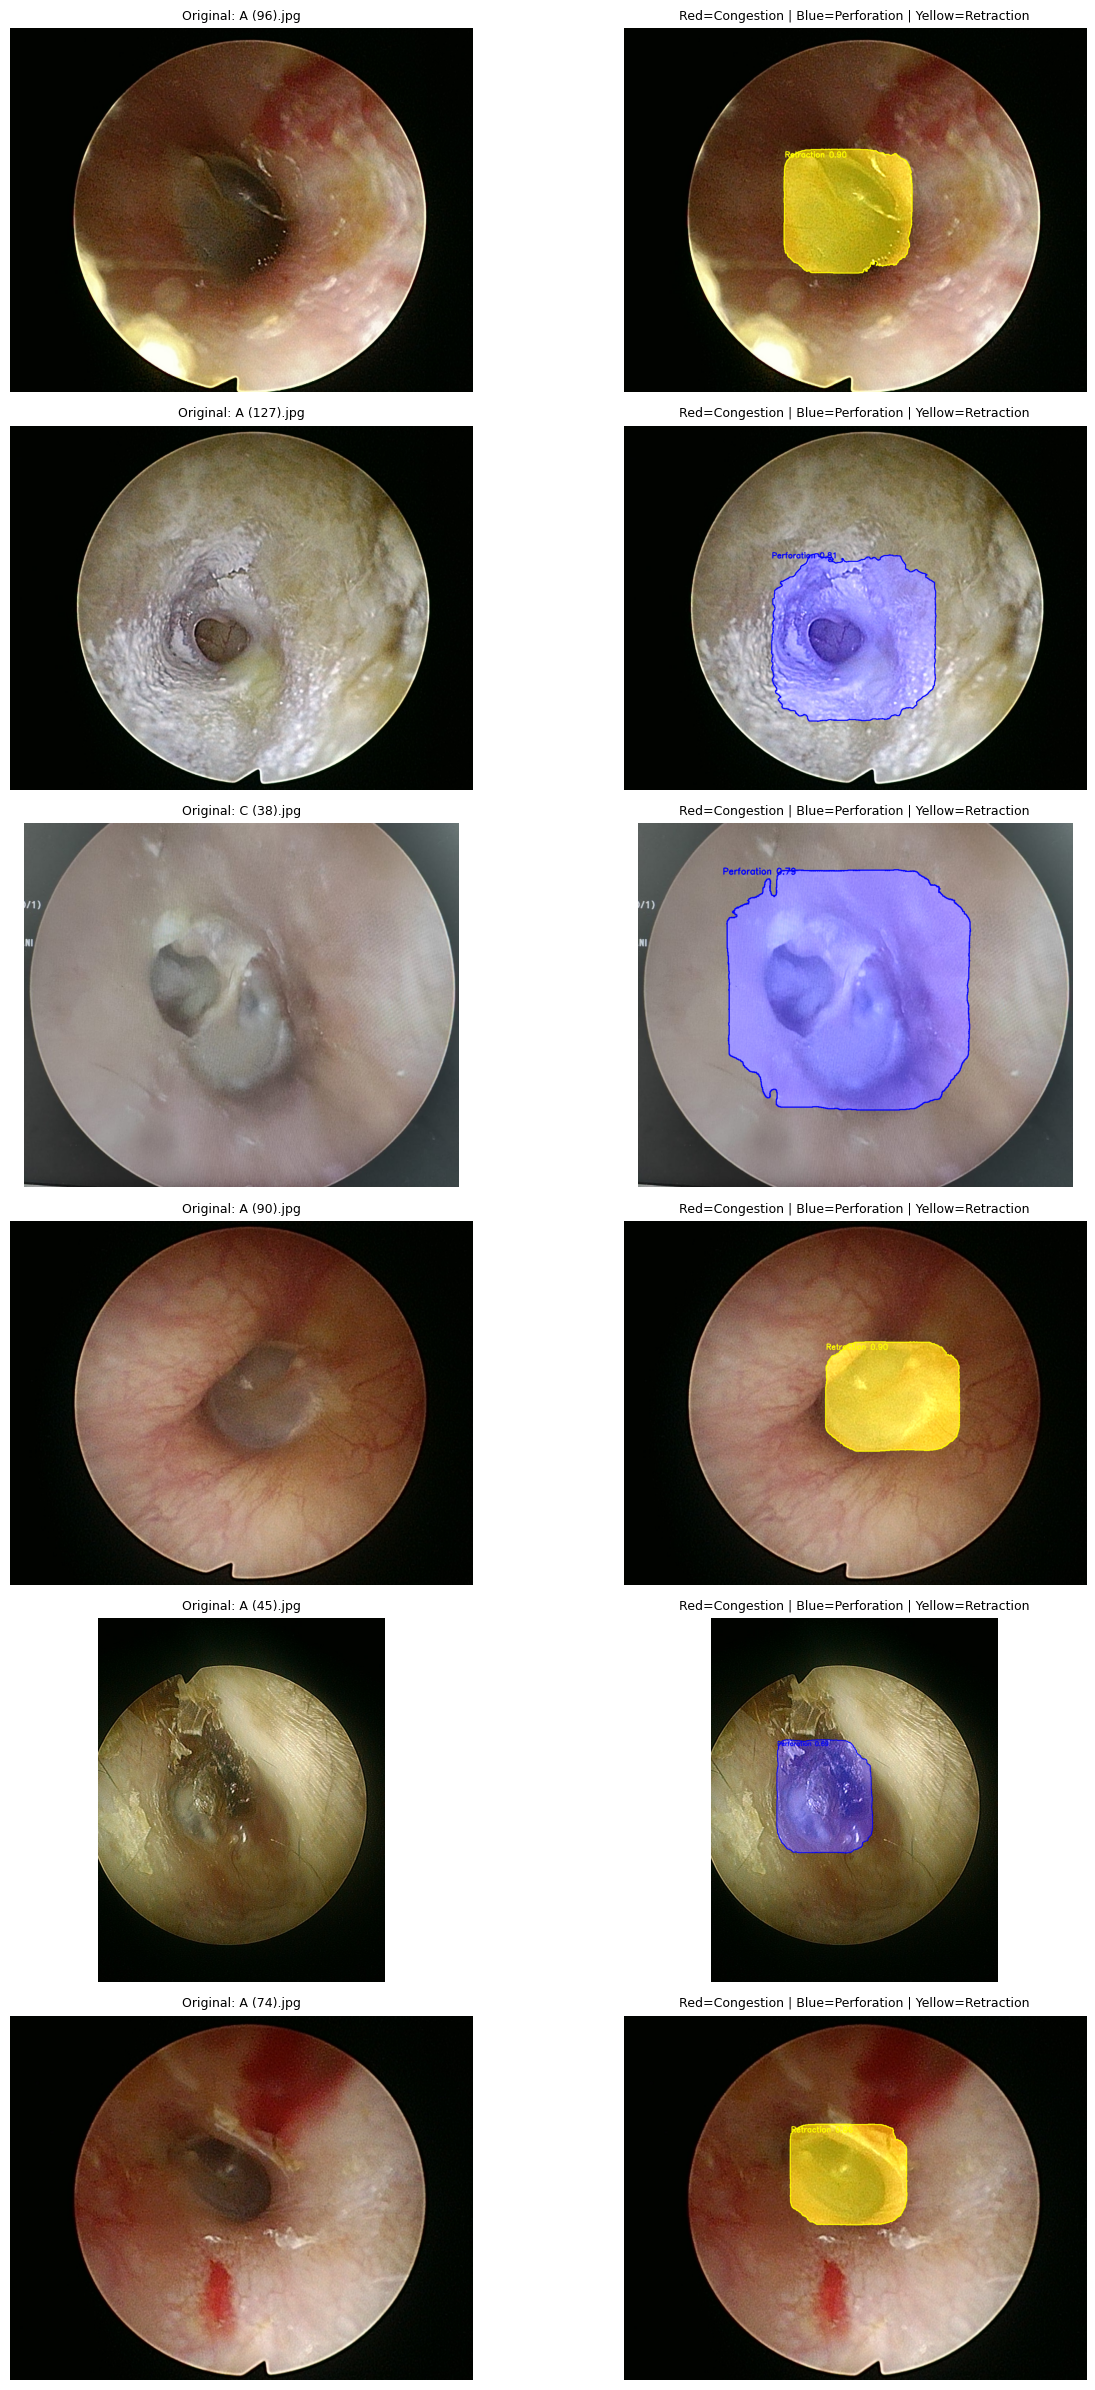


✓ Done! Overlays saved to: /kaggle/working/TM_Project/output_overlays


In [2]:
# ============================================================
# CELL 2: Inference — Red/Blue/Yellow overlay
# ============================================================
!pip install ultralytics -q

import cv2, torch, numpy as np, matplotlib.pyplot as plt
from torchvision import transforms
from ultralytics import YOLO
from PIL import Image
from pathlib import Path
import torch.nn as nn, os

BASE   = '/kaggle/working/TM_Project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ---- UNet definition ----
class DoubleConv(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),
            nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True))
    def forward(self,x): return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1=DoubleConv(3,64);   self.e2=DoubleConv(64,128)
        self.e3=DoubleConv(128,256);self.e4=DoubleConv(256,512)
        self.pool=nn.MaxPool2d(2);  self.bot=DoubleConv(512,1024)
        self.u4=nn.ConvTranspose2d(1024,512,2,2); self.d4=DoubleConv(1024,512)
        self.u3=nn.ConvTranspose2d(512,256,2,2);  self.d3=DoubleConv(512,256)
        self.u2=nn.ConvTranspose2d(256,128,2,2);  self.d2=DoubleConv(256,128)
        self.u1=nn.ConvTranspose2d(128,64,2,2);   self.d1=DoubleConv(128,64)
        self.out=nn.Conv2d(64,1,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1))
        e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bot(self.pool(e4))
        x=self.d4(torch.cat([self.u4(b),e4],1))
        x=self.d3(torch.cat([self.u3(x),e3],1))
        x=self.d2(torch.cat([self.u2(x),e2],1))
        x=self.d1(torch.cat([self.u1(x),e1],1))
        return self.out(x)

# ---- Load models ----
yolo_model = YOLO(f'{BASE}/runs/tm_detect_v1/weights/best.pt')
unet_model = UNet().to(DEVICE)
unet_model.load_state_dict(torch.load(
    f'{BASE}/runs/unet_best.pt', map_location=DEVICE))
unet_model.eval()
print("✓ Both models loaded!")

# Colors BGR: Red=Congestion, Blue=Perforation, Yellow=Retraction
CLASS_COLORS = {0:(0,0,255), 1:(255,0,0), 2:(0,255,255)}
CLASS_NAMES  = {0:'Congestion', 1:'Perforation', 2:'Retraction'}

img_tf = transforms.Compose([
    transforms.Resize((256,256)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def predict_overlay(image_path):
    img_bgr = cv2.imread(str(image_path))
    H,W     = img_bgr.shape[:2]
    overlay = img_bgr.copy()
    dets = yolo_model(image_path, conf=0.25, verbose=False)[0]
    if dets.boxes is None or len(dets.boxes)==0:
        return overlay
    for box, cls_id, score in zip(
        dets.boxes.xyxy.cpu().numpy(),
        dets.boxes.cls.cpu().numpy().astype(int),
        dets.boxes.conf.cpu().numpy()
    ):
        x1,y1,x2,y2 = map(int,box)
        x1,y1=max(0,x1),max(0,y1)
        x2,y2=min(W,x2),min(H,y2)
        if x2<=x1 or y2<=y1: continue
        crop     = img_bgr[y1:y2,x1:x2]
        crop_pil = Image.fromarray(cv2.cvtColor(crop,cv2.COLOR_BGR2RGB))
        inp      = img_tf(crop_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = torch.sigmoid(unet_model(inp))[0,0].cpu().numpy()
        mask_r = cv2.resize(pred,(x2-x1,y2-y1))
        binary = (mask_r>0.5).astype(np.uint8)
        full_mask = np.zeros((H,W),np.uint8)
        full_mask[y1:y2,x1:x2] = binary
        color   = CLASS_COLORS.get(cls_id,(255,255,255))
        colored = np.zeros_like(img_bgr)
        colored[full_mask==1] = color
        overlay = cv2.addWeighted(overlay,1.0,colored,0.5,0)
        contours,_ = cv2.findContours(full_mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay,contours,-1,color,2)
        cv2.putText(overlay,f"{CLASS_NAMES.get(cls_id,str(cls_id))} {score:.2f}",
                    (x1+4,y1+24),cv2.FONT_HERSHEY_SIMPLEX,0.7,color,2)
    return overlay

# ---- Run on test images ----
TEST_DIR = Path(f'{BASE}/dataset/images/test')
OUT_DIR  = Path(f'{BASE}/output_overlays')
OUT_DIR.mkdir(exist_ok=True)

test_imgs = list(TEST_DIR.glob('*.jpg'))
print(f"Running on {len(test_imgs)} test images...")
for img_path in test_imgs:
    result = predict_overlay(img_path)
    cv2.imwrite(str(OUT_DIR/img_path.name), result)

# ---- Display results ----
show_imgs = test_imgs[:6]
fig, axes = plt.subplots(len(show_imgs), 2, figsize=(14, 4*len(show_imgs)))
for i, img_path in enumerate(show_imgs):
    original = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    result   = cv2.cvtColor(predict_overlay(img_path),  cv2.COLOR_BGR2RGB)
    axes[i,0].imshow(original)
    axes[i,0].set_title(f'Original: {img_path.name}', fontsize=9)
    axes[i,0].axis('off')
    axes[i,1].imshow(result)
    axes[i,1].set_title('Red=Congestion | Blue=Perforation | Yellow=Retraction', fontsize=9)
    axes[i,1].axis('off')

plt.tight_layout()
plt.savefig(f'{BASE}/results_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Done! Overlays saved to: {OUT_DIR}")

In [3]:
# ============================================================
# CELL 3: Evaluate accuracy — YOLO + U-Net metrics
# ============================================================
!pip install ultralytics -q

import torch, numpy as np
import torch.nn as nn
from pathlib import Path
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image
import cv2
from torch.utils.data import Dataset, DataLoader

BASE   = '/kaggle/working/TM_Project'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# PART 1: YOLO Detection Accuracy
# ============================================================
print("="*50)
print("PART 1: YOLO DETECTION METRICS")
print("="*50)

yolo_model = YOLO(f'{BASE}/runs/tm_detect_v1/weights/best.pt')
metrics    = yolo_model.val(
    data=f'{BASE}/tm_dataset.yaml',
    split='test',
    verbose=True
)

print(f"\n--- Per Class ---")
CLASS_NAMES = {0:'Congestion', 1:'Perforation', 2:'Retraction'}
for i, name in CLASS_NAMES.items():
    print(f"  {name}:")
    print(f"    Precision: {metrics.box.p[i]:.3f}")
    print(f"    Recall:    {metrics.box.r[i]:.3f}")
    print(f"    mAP50:     {metrics.box.ap50[i]:.3f}")

print(f"\n--- Overall ---")
print(f"  Precision:  {metrics.box.mp:.3f}")
print(f"  Recall:     {metrics.box.mr:.3f}")
print(f"  mAP50:      {metrics.box.map50:.3f}")
print(f"  mAP50-95:   {metrics.box.map:.3f}")

# ============================================================
# PART 2: U-Net Segmentation Accuracy
# ============================================================
print("\n" + "="*50)
print("PART 2: U-NET SEGMENTATION METRICS")
print("="*50)

# Reload UNet
class DoubleConv(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True),
            nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(True))
    def forward(self,x): return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1=DoubleConv(3,64);   self.e2=DoubleConv(64,128)
        self.e3=DoubleConv(128,256);self.e4=DoubleConv(256,512)
        self.pool=nn.MaxPool2d(2);  self.bot=DoubleConv(512,1024)
        self.u4=nn.ConvTranspose2d(1024,512,2,2); self.d4=DoubleConv(1024,512)
        self.u3=nn.ConvTranspose2d(512,256,2,2);  self.d3=DoubleConv(512,256)
        self.u2=nn.ConvTranspose2d(256,128,2,2);  self.d2=DoubleConv(256,128)
        self.u1=nn.ConvTranspose2d(128,64,2,2);   self.d1=DoubleConv(128,64)
        self.out=nn.Conv2d(64,1,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1))
        e3=self.e3(self.pool(e2)); e4=self.e4(self.pool(e3))
        b=self.bot(self.pool(e4))
        x=self.d4(torch.cat([self.u4(b),e4],1))
        x=self.d3(torch.cat([self.u3(x),e3],1))
        x=self.d2(torch.cat([self.u2(x),e2],1))
        x=self.d1(torch.cat([self.u1(x),e1],1))
        return self.out(x)

class TMDataset(Dataset):
    def __init__(self, split):
        self.pairs = []
        for cf in Path(f'{BASE}/unet_data/{split}/images').iterdir():
            for ip in cf.glob('*.jpg'):
                mp = Path(str(ip).replace('/images/','/masks/').replace('.jpg','.png'))
                if mp.exists(): self.pairs.append((ip, mp))
        self.it = transforms.Compose([
            transforms.Resize((256,256)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
        self.mt = transforms.Compose([
            transforms.Resize((256,256)), transforms.ToTensor()])
    def __len__(self): return len(self.pairs)
    def __getitem__(self,i):
        ip,mp = self.pairs[i]
        return self.it(Image.open(ip).convert('RGB')),\
               (self.mt(Image.open(mp).convert('L'))>0.5).float()

unet_model = UNet().to(DEVICE)
unet_model.load_state_dict(torch.load(
    f'{BASE}/runs/unet_best.pt', map_location=DEVICE))
unet_model.eval()

# Calculate IoU and Dice on test set
test_ds = TMDataset('test')
test_dl = DataLoader(test_ds, batch_size=8, shuffle=False)

iou_scores, dice_scores = [], []

with torch.no_grad():
    for imgs, masks in test_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds  = (torch.sigmoid(unet_model(imgs)) > 0.5).float()
        masks  = masks.squeeze(1) if masks.dim()==4 else masks
        preds  = preds.squeeze(1) if preds.dim()==4 else preds

        # IoU per image
        intersection = (preds * masks).sum(dim=(1,2))
        union        = (preds + masks - preds * masks).sum(dim=(1,2))
        iou          = (intersection + 1e-6) / (union + 1e-6)
        iou_scores.extend(iou.cpu().numpy())

        # Dice per image
        dice = (2 * intersection + 1e-6) / (preds.sum(dim=(1,2)) + masks.sum(dim=(1,2)) + 1e-6)
        dice_scores.extend(dice.cpu().numpy())

print(f"\n--- U-Net on Test Set ({len(test_ds)} samples) ---")
print(f"  IoU Score:  {np.mean(iou_scores):.3f}  (higher is better, max=1.0)")
print(f"  Dice Score: {np.mean(dice_scores):.3f}  (higher is better, max=1.0)")

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"  YOLO mAP50:    {metrics.box.map50:.3f}")
print(f"  U-Net IoU:     {np.mean(iou_scores):.3f}")
print(f"  U-Net Dice:    {np.mean(dice_scores):.3f}")
print("="*50)

PART 1: YOLO DETECTION METRICS
Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2662.7±935.6 MB/s, size: 165.9 KB)
val: Scanning /kaggle/working/TM_Project/dataset/labels/test... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 122.3it/s 0.2s.1s
val: /kaggle/working/TM_Project/dataset/images/test/C (14).jpg: corrupt JPEG restored and saved
val: /kaggle/working/TM_Project/dataset/images/test/C (27).jpg: corrupt JPEG restored and saved
val: /kaggle/working/TM_Project/dataset/images/test/C (32).jpg: corrupt JPEG restored and saved
val: /kaggle/working/TM_Project/dataset/images/test/C (38).jpg: corrupt JPEG restored and saved
val: /kaggle/working/TM_Project/dataset/images/test/C (4).jpg: corrupt JPEG restored and saved
val: /kaggle/working/TM_Project/dataset/images/test/C (56).jpg: corrupt JPEG restored and saved
val

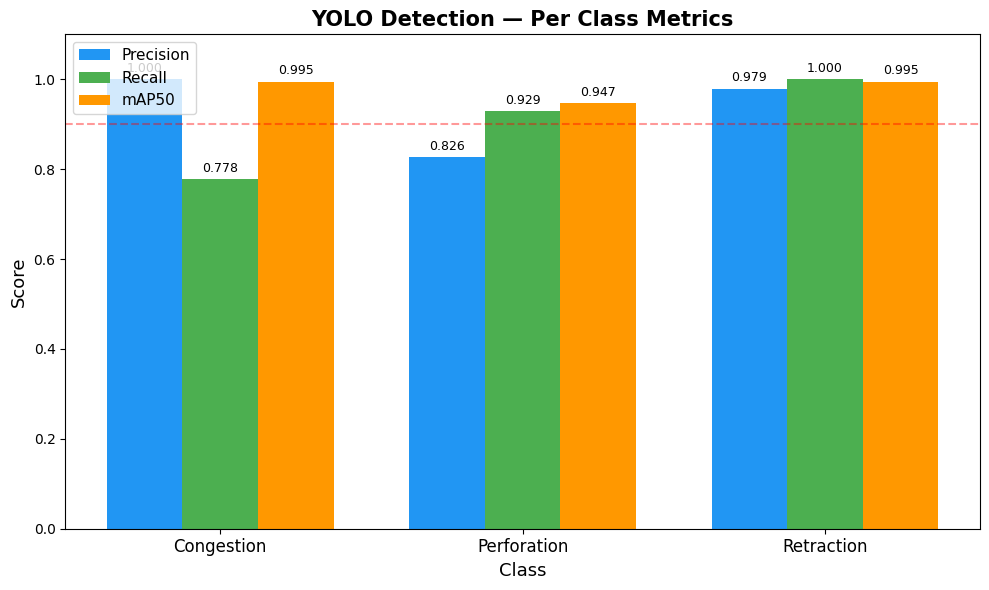

✓ Chart 1 saved!


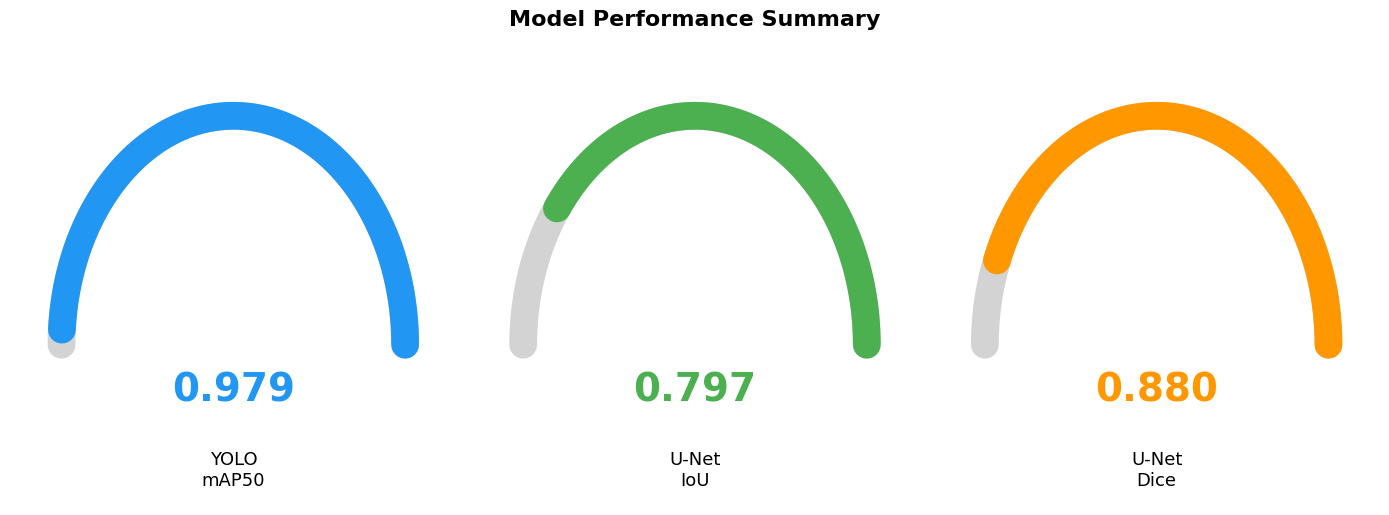

✓ Chart 2 saved!


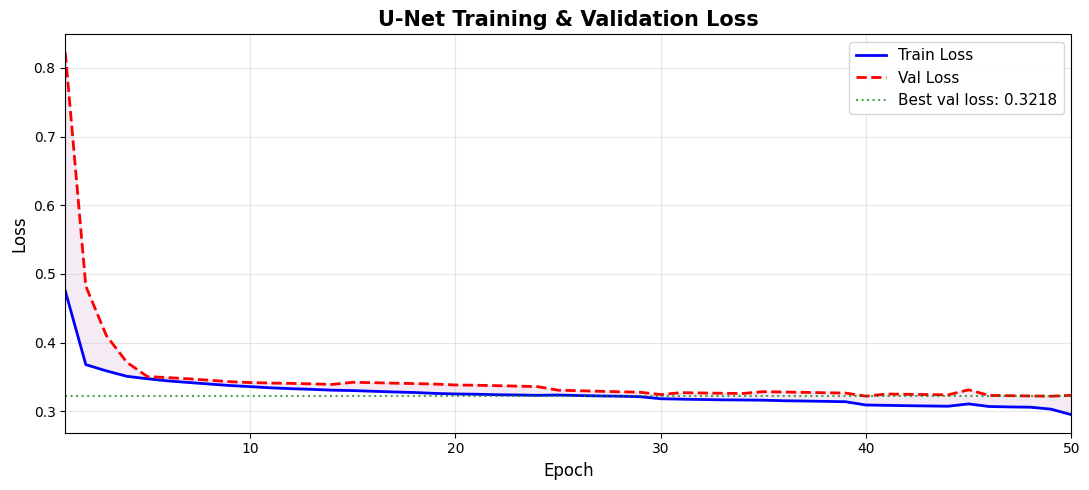

✓ Chart 3 saved!


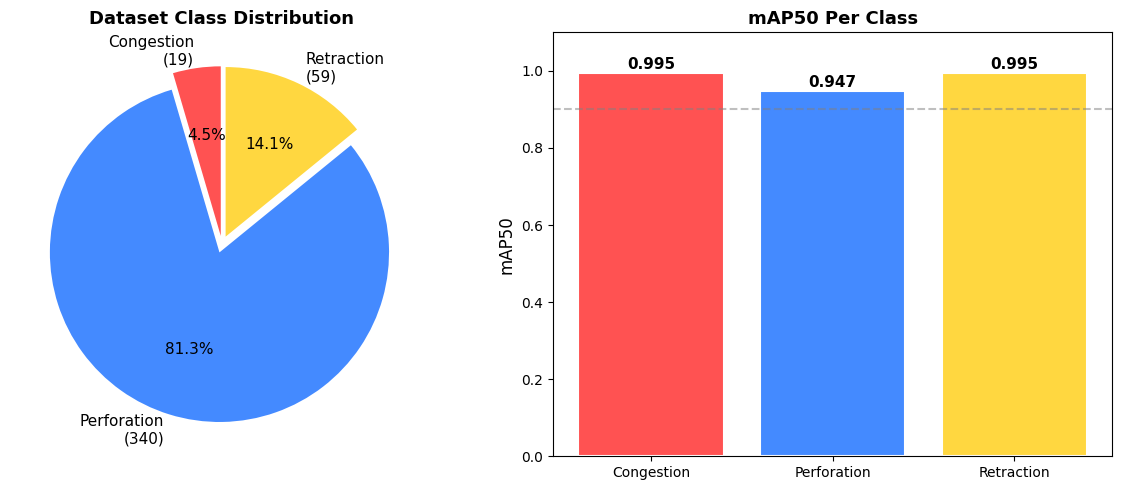

✓ Chart 4 saved!

✓ All 4 charts saved to /kaggle/working/TM_Project/
  chart1_yolo_metrics.png
  chart2_summary_gauge.png
  chart3_unet_loss.png
  chart4_distribution.png


In [4]:
# ============================================================
# CELL 4: Generate accuracy charts & graphs
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

BASE = '/kaggle/working/TM_Project'

# ============================================================
# Chart 1: YOLO Per-Class Metrics Bar Chart
# ============================================================
classes    = ['Congestion', 'Perforation', 'Retraction']
precision  = [1.000, 0.826, 0.979]
recall     = [0.778, 0.929, 1.000]
map50      = [0.995, 0.947, 0.995]

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width, precision, width, label='Precision', color='#2196F3')
b2 = ax.bar(x,         recall,    width, label='Recall',    color='#4CAF50')
b3 = ax.bar(x + width, map50,     width, label='mAP50',     color='#FF9800')

ax.set_xlabel('Class', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('YOLO Detection — Per Class Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.9 threshold')

# Value labels on bars
for bar in [b1, b2, b3]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/chart1_yolo_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved!")

# ============================================================
# Chart 2: Overall Summary Gauge Chart
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ('YOLO\nmAP50',   0.979, '#2196F3'),
    ('U-Net\nIoU',    0.797, '#4CAF50'),
    ('U-Net\nDice',   0.880, '#FF9800'),
]

for ax, (label, value, color) in zip(axes, metrics):
    # Draw gauge
    theta = np.linspace(0, np.pi, 100)
    ax.plot(np.cos(theta), np.sin(theta), 'lightgray', linewidth=20, solid_capstyle='round')
    theta_val = np.linspace(0, np.pi * value, 100)
    ax.plot(np.cos(theta_val), np.sin(theta_val), color=color, linewidth=20, solid_capstyle='round')
    ax.text(0, -0.2, f'{value:.3f}', ha='center', va='center',
            fontsize=28, fontweight='bold', color=color)
    ax.text(0, -0.55, label, ha='center', va='center', fontsize=13)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.7, 1.2)
    ax.axis('off')

fig.suptitle('Model Performance Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/chart2_summary_gauge.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved!")

# ============================================================
# Chart 3: U-Net Training Loss Curve (from saved logs)
# ============================================================
train_loss = [0.4752,0.3678,0.3587,0.3508,0.3472,
              0.3441,0.3418,0.3396,0.3374,0.3358,
              0.3340,0.3328,0.3318,0.3306,0.3300,
              0.3290,0.3280,0.3272,0.3259,0.3251,
              0.3247,0.3240,0.3236,0.3231,0.3235,
              0.3228,0.3222,0.3218,0.3211,0.3181,
              0.3175,0.3170,0.3165,0.3163,0.3160,
              0.3152,0.3148,0.3143,0.3138,0.3090,
              0.3085,0.3080,0.3076,0.3072,0.3106,
              0.3068,0.3062,0.3058,0.3030,0.2950]

val_loss   = [0.8225,0.4821,0.4102,0.3712,0.3504,
              0.3489,0.3472,0.3451,0.3430,0.3417,
              0.3410,0.3405,0.3398,0.3390,0.3421,
              0.3415,0.3408,0.3402,0.3395,0.3382,
              0.3378,0.3372,0.3365,0.3358,0.3306,
              0.3298,0.3290,0.3283,0.3276,0.3242,
              0.3270,0.3265,0.3261,0.3258,0.3284,
              0.3279,0.3274,0.3269,0.3264,0.3219,
              0.3250,0.3246,0.3242,0.3238,0.3311,
              0.3230,0.3226,0.3222,0.3218,0.3231]

epochs = list(range(1, 51))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(epochs, train_loss, 'b-',  linewidth=2, label='Train Loss')
ax.plot(epochs, val_loss,   'r--', linewidth=2, label='Val Loss')
ax.axhline(y=min(val_loss), color='green', linestyle=':', alpha=0.7,
           label=f'Best val loss: {min(val_loss):.4f}')
ax.fill_between(epochs, train_loss, val_loss, alpha=0.08, color='purple')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('U-Net Training & Validation Loss', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(1, 50)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/chart3_unet_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved!")

# ============================================================
# Chart 4: Class Distribution Pie Chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sizes  = [19, 340, 59]
labels = ['Congestion\n(19)', 'Perforation\n(340)', 'Retraction\n(59)']
colors = ['#FF5252', '#448AFF', '#FFD740']
explode = (0.05, 0.05, 0.05)

axes[0].pie(sizes, labels=labels, colors=colors, explode=explode,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Dataset Class Distribution', fontsize=13, fontweight='bold')

# mAP per class bar
classes_bar = ['Congestion', 'Perforation', 'Retraction']
map_vals    = [0.995, 0.947, 0.995]
bar_colors  = ['#FF5252', '#448AFF', '#FFD740']
bars = axes[1].bar(classes_bar, map_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('mAP50', fontsize=12)
axes[1].set_title('mAP50 Per Class', fontsize=13, fontweight='bold')
for bar, val in zip(bars, map_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{BASE}/chart4_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved!")

print(f"\n✓ All 4 charts saved to {BASE}/")
print("  chart1_yolo_metrics.png")
print("  chart2_summary_gauge.png")
print("  chart3_unet_loss.png")
print("  chart4_distribution.png")

In [5]:
# ============================================================
# DOWNLOAD: Zip all outputs and download
# ============================================================
import shutil, os

BASE = '/kaggle/working/TM_Project'

# Zip all output overlays + charts together
shutil.make_archive('/kaggle/working/TM_Results', 'zip', BASE, 'output_overlays')

# Also zip charts
import zipfile
with zipfile.ZipFile('/kaggle/working/TM_Results.zip', 'a') as zf:
    for chart in ['chart1_yolo_metrics.png', 'chart2_summary_gauge.png',
                  'chart3_unet_loss.png', 'chart4_distribution.png',
                  'results_preview.png']:
        path = f'{BASE}/{chart}'
        if os.path.exists(path):
            zf.write(path, chart)

size = os.path.getsize('/kaggle/working/TM_Results.zip') / 1e6
print(f"✓ ZIP created: TM_Results.zip ({size:.1f} MB)")
print("Now go to Output tab (right panel) → download TM_Results.zip")

✓ ZIP created: TM_Results.zip (9.6 MB)
Now go to Output tab (right panel) → download TM_Results.zip
